# Import Required Libraries
Import the necessary libraries, including pandas, numpy, scikit-learn, and matplotlib.

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better visualization
sns.set(style="whitegrid")

# Load and Prepare Dataset
Load the dataset and perform any necessary preprocessing steps.

In [2]:
# Load the dataset
data = pd.read_csv("../datasets/master_dataset.csv")

# Display the first few rows of the dataset
data.head()

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Drop rows with missing values (if any)
data = data.dropna()

# Encode categorical variables (if any)
# Example: data['category_column'] = data['category_column'].astype('category').cat.codes

# Split the data into features and target variable
X = data.drop('winner', axis=1)
y = data['winner']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Missing values in each column:
 timestamp                             0
BLUE.HEXTECH_DRAGON.kills             0
BLUE.WATER_DRAGON.kills               0
BLUE.FIRE_DRAGON.kills                0
BLUE.EARTH_DRAGON.kills               0
BLUE.AIR_DRAGON.kills                 0
BLUE.CHEMTECH_DRAGON.kills            0
BLUE.ELDER_DRAGON.kills               0
BLUE.RIFTHERALD.kills                 0
BLUE.BARON_NASHOR.kills               0
BLUE.HORDE.kills                      0
BLUE.ATAKHAN.kills                    0
RED.HEXTECH_DRAGON.kills              0
RED.WATER_DRAGON.kills                0
RED.FIRE_DRAGON.kills                 0
RED.EARTH_DRAGON.kills                0
RED.AIR_DRAGON.kills                  0
RED.CHEMTECH_DRAGON.kills             0
RED.ELDER_DRAGON.kills                0
RED.RIFTHERALD.kills                  0
RED.BARON_NASHOR.kills                0
RED.HORDE.kills                       0
RED.ATAKHAN.kills                     0
BLUE.TOWER_BUILDING.kills             0
RED.TOWE

# Split Data into Training and Testing Sets
Split the dataset into training and testing sets using train_test_split from scikit-learn.

In [3]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display the shapes of the training and testing sets
print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)

Training set shape: (3050696, 41) (3050696,)
Testing set shape: (762675, 41) (762675,)


# Feature Engineering
Perform any necessary feature engineering and document the steps.

In [4]:
# Feature Engineering

# Normalize numerical features
from sklearn.preprocessing import StandardScaler

# Replace infinity values with a large finite number
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the mean of the column
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Display the first few rows of the scaled training set
print("First few rows of the scaled training set:\n", pd.DataFrame(X_train_scaled, columns=X_train.columns).head())

# Feature selection (if necessary)
# Example: Select top k features using SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# Display the scores of the features
feature_scores = selector.scores_
print("Feature scores:\n", feature_scores)

# Display the first few rows of the selected training set
print("First few rows of the selected training set:\n", pd.DataFrame(X_train_selected, columns=X_train.columns[selector.get_support()]).head())

First few rows of the scaled training set:
    timestamp  BLUE.HEXTECH_DRAGON.kills  BLUE.WATER_DRAGON.kills  \
0   0.567695                  -0.380679                -0.380562   
1   1.500264                  -0.380679                -0.380562   
2   0.567503                   2.244050                -0.380562   
3  -0.131796                   2.244050                -0.380562   
4   0.334528                  -0.380679                -0.380562   

   BLUE.FIRE_DRAGON.kills  BLUE.EARTH_DRAGON.kills  BLUE.AIR_DRAGON.kills  \
0               -0.383874                -0.381307               2.252777   
1               -0.383874                -0.381307              -0.379094   
2               -0.383874                -0.381307              -0.379094   
3               -0.383874                -0.381307              -0.379094   
4               -0.383874                -0.381307              -0.379094   

   BLUE.CHEMTECH_DRAGON.kills  BLUE.ELDER_DRAGON.kills  BLUE.RIFTHERALD.kills  \
0  

# Train Logistic Regression Model
Train the Logistic Regression model on the training dataset and save the trained model.

In [5]:
# Train the Logistic Regression model on the training dataset
logistic_regression_model = LogisticRegression(random_state=42)
logistic_regression_model.fit(X_train_selected, y_train)

# Save the trained model using joblib
import joblib
joblib.dump(logistic_regression_model, 'logistic_regression_model.pkl')

# Display a message indicating the model has been trained and saved
print("Logistic Regression model has been trained and saved as 'logistic_regression_model.pkl'")

Logistic Regression model has been trained and saved as 'logistic_regression_model.pkl'


# Hyperparameter Tuning
Perform hyperparameter tuning using GridSearchCV and save the best model.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for hyperparameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Initialize the GridSearchCV object
grid_search = GridSearchCV(estimator=LogisticRegression(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train_selected, y_train)

# Get the best parameters and the best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

# Print the best parameters and the best score
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Score: {best_score:.4f}")

# Save the best model
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'best_logistic_regression_model.pkl')

# Display a message indicating the best model has been saved
print("Best Logistic Regression model has been saved as 'best_logistic_regression_model.pkl'")

# Evaluate Model Performance
Evaluate the model on the testing dataset using metrics such as Accuracy, Precision, Recall, F1-Score, and AUC-ROC.

Brier Score: 0.1614
Accuracy: 0.7569
Precision: 0.7574
Recall: 0.7450
F1-Score: 0.7512
AUC-ROC: 0.8438


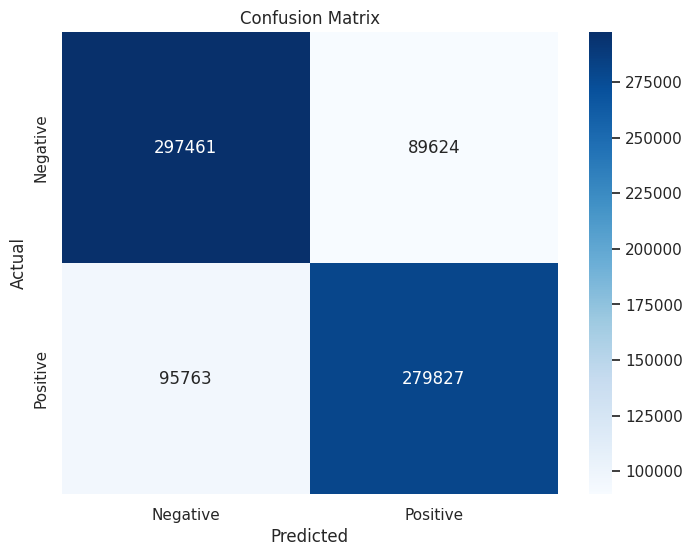

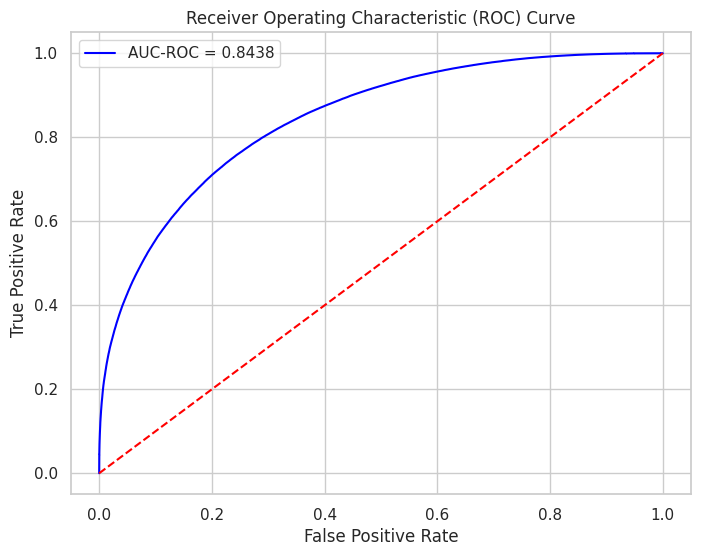

In [6]:
from sklearn.metrics import brier_score_loss

# Load the best model
best_model = joblib.load('best_logistic_regression_model.pkl')

# Predict the target variable on the testing dataset
y_pred = best_model.predict(X_test_selected)
y_pred_proba = best_model.predict_proba(X_test_selected)[:, 1]


# Calculate the Brier score
brier_score = brier_score_loss(y_test, y_pred_proba)
print(f"Brier Score: {brier_score:.4f}")
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

# Print evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc_roc:.4f}')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

## Prediction Over Time

In [18]:
df_chall = pd.read_csv('../datasets/challenger_dataset.csv')
df = df_chall

df = df[df['timestamp'] != 0]
df = df[~df.isin([np.inf, -np.inf]).any(axis=1)]
df.fillna(df.median(), inplace=True)
a = df['timestamp']
df.drop(columns=['timestamp'], inplace=True)



In [19]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# normalization
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols.remove('winner')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

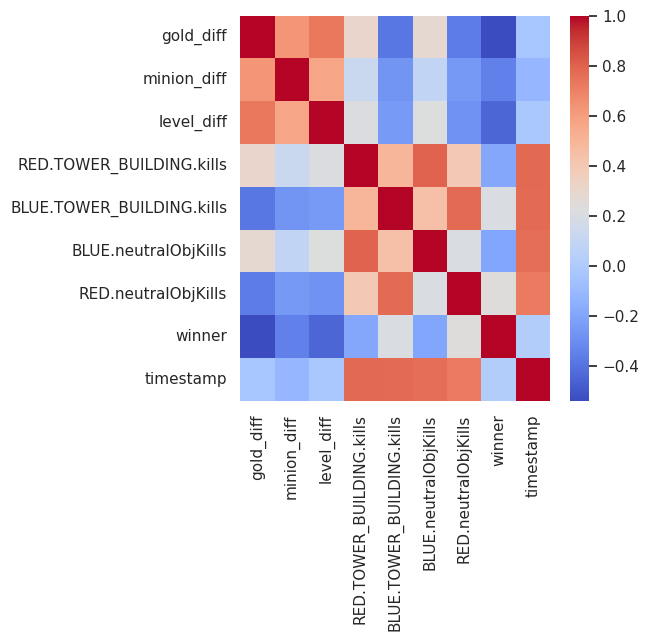

In [21]:
tdf = df.copy()
tdf = tdf.drop(columns=df.columns)
tdf['gold_diff'] = df['BLUE.totalGoldRatio'] - df['RED.totalGoldRatio']
tdf['minion_diff'] = df['BLUE.minionRatio'] - df['RED.minionRatio']
tdf['level_diff'] = df['BLUE.levelRatio'] - df['RED.levelRatio']

tdf['RED.TOWER_BUILDING.kills'] = df['RED.TOWER_BUILDING.kills']
tdf['BLUE.TOWER_BUILDING.kills'] = df['BLUE.TOWER_BUILDING.kills']

tdf["BLUE.neutralObjKills"] = df["BLUE.HEXTECH_DRAGON.kills"] + df["BLUE.WATER_DRAGON.kills"] + \
                                df["BLUE.FIRE_DRAGON.kills"] + df["BLUE.EARTH_DRAGON.kills"] + \
                                df["BLUE.AIR_DRAGON.kills"] + df["BLUE.ELDER_DRAGON.kills"] + \
                                df["BLUE.RIFTHERALD.kills"] + df["BLUE.BARON_NASHOR.kills"] + \
                                df["BLUE.ATAKHAN.kills"] + df["BLUE.CHEMTECH_DRAGON.kills"] + \
                                df["BLUE.HORDE.kills"]

tdf["RED.neutralObjKills"] = df["RED.HEXTECH_DRAGON.kills"] + df["RED.WATER_DRAGON.kills"] + \
                                df["RED.FIRE_DRAGON.kills"] + df["RED.EARTH_DRAGON.kills"] + \
                                df["RED.AIR_DRAGON.kills"] + df["RED.ELDER_DRAGON.kills"] + \
                                df["RED.RIFTHERALD.kills"] + df["RED.BARON_NASHOR.kills"] + \
                                df["RED.ATAKHAN.kills"] + df["RED.CHEMTECH_DRAGON.kills"] + \
                                df["RED.HORDE.kills"]
tdf['winner'] = df['winner']
tdf["timestamp"] = a

correlationMat = tdf.corr()

# Set the size of the plot
plt.figure(figsize=(5, 5))

# Create a heatmap of the correlation matrix
sns.heatmap(correlationMat, annot=False, cmap='coolwarm')

# Display the plot
plt.show()

In [22]:
# final split 
X = tdf.drop('winner', axis=1)[:100000]
y = tdf['winner'][:100000]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(80000, 8) (20000, 8) (80000,) (20000,)


/home/youngsnow/Documents/UniversityKent/AISystemImpl/LeagueOfLegendsModelBenchmark/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


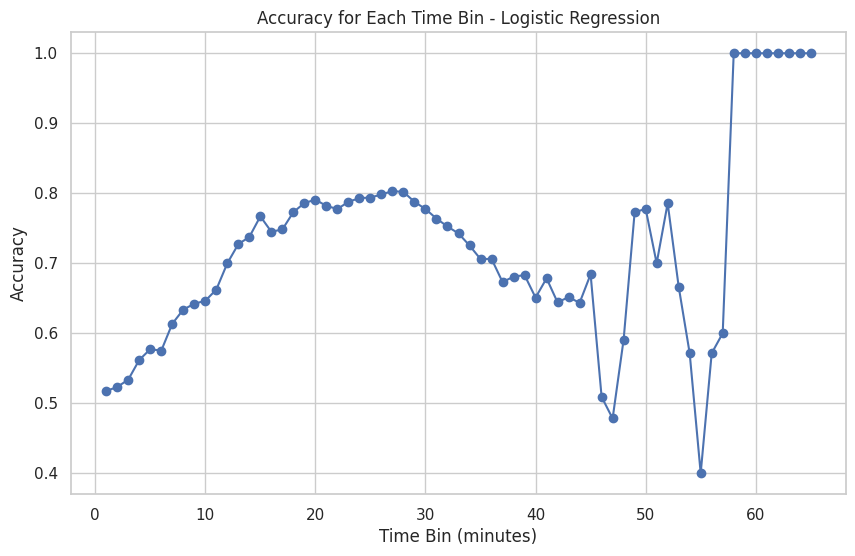

In [23]:
import joblib

tdf["time_bin"] = (tdf["timestamp"] // 60000) * 60000

# load the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

def predict_regressor(model, X_test, y_test):
    pred = model.predict(X_test)
    return accuracy_score(y_test, np.round(np.clip(pred, 0, 1)))

def plot_accuracy_over_time(model, label, df, prediction):
    minutes = []
    accuracies = []
    for time_bin, df_bin in df.groupby("time_bin"):
        minutes.append(time_bin // 60000)
        X_test_bin = df_bin.drop(columns=["winner", "time_bin"])
        y_test_bin = df_bin["winner"]
        accuracies.append(prediction(model, X_test_bin, y_test_bin))

    plt.figure(figsize=(10, 6))
    plt.plot(minutes, accuracies, marker='o', linestyle='-')
    plt.title(f'Accuracy for Each Time Bin - {label}')
    plt.xlabel('Time Bin (minutes)')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.show()

plot_accuracy_over_time(model, 'Logistic Regression', tdf, predict_regressor)